In [2]:
import os

import random

import numpy as np

import cv2

import matplotlib.pyplot as plt
import seaborn as sns

from keras.applications import DenseNet169
from keras.models import Sequential
from keras import layers
from keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from tqdm.notebook import tqdm

from src.module.ai_module import apply_preprocessing

In [3]:
path = "dataset"

In [4]:
os.chdir("..")
os.chdir("..")
os.chdir(path)

In [5]:
labels = ["0", "1", "2", "3", "4"]
img_size = 128

In [6]:
def get_data(data_dir):  # train setindeki hasta sayısı ile sınırlandır

    data = list()

    for label in labels:
        class_id = labels.index(label)  # 'NORMAL' = 0, 'STROKE' = 1
        main_dir = os.path.join(os.getcwd(), data_dir)
        main_dir = os.path.join(main_dir, label)

        for img_name in tqdm(os.listdir(main_dir)):

            try:
                # read image
                img = cv2.imread(os.path.join(main_dir, img_name), cv2.IMREAD_COLOR)

                # apply preprocessing
                img = apply_preprocessing(img, img_size)

                data.append([img, class_id])


            except Exception as e:
                print(e)

    return data

In [7]:
train = get_data("TRAIN")

  0%|          | 0/1181 [00:00<?, ?it/s]

  0%|          | 0/1054 [00:00<?, ?it/s]

  0%|          | 0/1122 [00:00<?, ?it/s]

  0%|          | 0/1159 [00:00<?, ?it/s]

  0%|          | 0/1168 [00:00<?, ?it/s]

In [8]:
test = get_data("TEST")

  0%|          | 0/192 [00:00<?, ?it/s]

  0%|          | 0/192 [00:00<?, ?it/s]

  0%|          | 0/192 [00:00<?, ?it/s]

  0%|          | 0/192 [00:00<?, ?it/s]

  0%|          | 0/192 [00:00<?, ?it/s]

In [9]:
random.shuffle(train)
random.shuffle(test)

In [10]:
print(len(train), len(test))

5684 960


In [11]:
train = np.array(train, dtype='object')
test = np.array(test, dtype='object')

In [12]:
x_train, y_train = list(), list()
x_test, y_test = list(), list()

for feat, label in train:
    x_train.append(feat)  # görseller
    y_train.append(label)  # etiketler

In [13]:
for feat, label in test:
    x_test.append(feat)
    y_test.append(label)

In [14]:
# normalization : [0,255] -> [0,1]

x_train = np.array(x_train) / 255
x_test = np.array(x_test) / 255

In [15]:
x_train = x_train.reshape(-1, img_size, img_size, 3)  # -1 : oto 
x_test = x_test.reshape(-1, img_size, img_size, 3)

In [17]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [51]:
model_name = "DenseNet169_128px"  # VGG16



In [52]:
from keras.saving.save import load_model

model = load_model(f"models/{model_name}.h5")

In [28]:
"""model = Sequential()
model.add(DenseNet169(weights='imagenet', include_top=False, input_shape=(img_size, img_size, 3)))
model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dropout(0.3))  # Daha az dropout
model.add(layers.Dense(5, activation='softmax'))  # sigmoid yerine softmax"""

51877672/51877672 [==============================] - 25s 0us/step


In [53]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [54]:
lr = ReduceLROnPlateau(monitor='val_loss',
                       patience=3,
                       verbose=1,
                       mode='auto',
                       factor=0.25,
                       min_lr=1e-6)

In [73]:
history = model.fit(x_train, y_train,
                    batch_size=4,
                    epochs=2,
                    validation_data=(x_test, y_test),
                    callbacks=[lr])


Epoch 1/2
1421/1421 [==============================] - 233s 164ms/step - loss: 0.2121 - accuracy: 0.9316 - val_loss: 1.3033 - val_accuracy: 0.6135 - lr: 6.2500e-05
Epoch 2/2
1421/1421 [==============================] - 269s 190ms/step - loss: 0.1715 - accuracy: 0.9462 - val_loss: 1.3353 - val_accuracy: 0.6250 - lr: 6.2500e-05


In [74]:
# History'den eğitim ve doğrulama metriklerini alma
history_dict = history.history

In [75]:
# Eğitim ve doğrulama kaybı (loss)
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

In [76]:
# Eğitim ve doğrulama doğruluğu (accuracy)
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']

In [77]:
epochs = range(1, len(loss_values) + 1)

In [78]:
# Modelin tahminleri
y_pred_probs = model.predict(x_test)  # softmax çıktıları
y_pred = np.argmax(y_pred_probs, axis=1)  # en yüksek olasılığı al


30/30 [==============================] - 1s 30ms/step


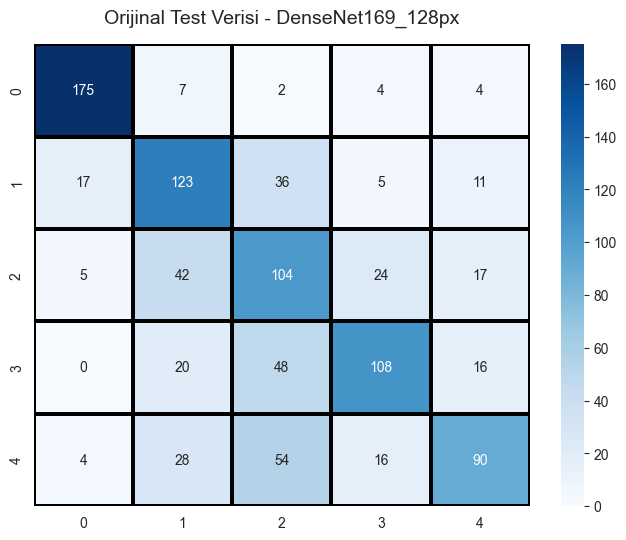

In [79]:
cm = confusion_matrix(y_test, y_pred)

# Isı haritası çiz
plt.figure(figsize=(8, 6))  # Daha büyük bir figür boyutu
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", linewidths=1.5, linecolor='black',
            xticklabels=set(y_test), yticklabels=set(y_test))

plt.title(f"Orijinal Test Verisi - {model_name}", fontsize=14, pad=15)
plt.show()

In [80]:
print("accuracy : \n", accuracy_score(y_test, y_pred))
print("cr : \n", classification_report(y_test, y_pred))

accuracy : 
 0.625
cr : 
               precision    recall  f1-score   support

           0       0.87      0.91      0.89       192
           1       0.56      0.64      0.60       192
           2       0.43      0.54      0.48       192
           3       0.69      0.56      0.62       192
           4       0.65      0.47      0.55       192

    accuracy                           0.62       960
   macro avg       0.64      0.62      0.63       960
weighted avg       0.64      0.62      0.63       960



In [81]:
os.chdir("..")


In [82]:
import json
import numpy as np
from tensorflow.keras.models import model_from_config


def fix_json_serialization(value):
    if isinstance(value, np.ndarray):
        return value.tolist()
    if hasattr(value, "numpy"):  # Tensor ise
        return value.numpy().tolist()
    return value


# Model konfigürasyonunu al
config = model.get_config()

# JSON'a uygun hale getir
fixed_config = json.loads(json.dumps(config, default=fix_json_serialization))

# Sequential modelse model_from_config ile tekrar yükle
from tensorflow.keras.models import Sequential

fixed_model = Sequential.from_config(fixed_config)

# Ağırlıkları aktar
fixed_model.set_weights(model.get_weights())

# Kaydet
fixed_model.save(f"models/{model_name}.h5")